# 📊 EDA — DravidianCodeMix-2020 Preprocessing Pipeline

### Exploratory Data Analysis for Sentiment & Offensive Language Detection

This notebook performs a comprehensive EDA on the DravidianCodeMix-2020 dataset, covering:
1. **Raw Data Exploration** — Dataset sizes, label distributions, text statistics
2. **Before vs After Preprocessing** — Impact of cleaning
3. **Code-Mixing Analysis** — Script detection, CMI distribution
4. **Text Length Analysis** — Character/word distributions per language
5. **Label Distribution Visualization** — Class imbalance analysis
6. **Correlation & Feature Analysis** — Relationships between features

---


In [1]:
# ══════════════════════════════════════════════════════
# SETUP & IMPORTS
# ══════════════════════════════════════════════════════
import os
import sys
import warnings
warnings.filterwarnings('ignore')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from collections import Counter

# Set plotting style
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")
plt.rcParams['figure.figsize'] = (14, 6)
plt.rcParams['figure.dpi'] = 100
plt.rcParams['font.size'] = 11
plt.rcParams['axes.titlesize'] = 14
plt.rcParams['axes.labelsize'] = 12

# Import our preprocessing pipeline
sys.path.insert(0, os.path.dirname(os.path.abspath('.')))
from preprocessing_pipeline import *

print("✅ All imports successful!")
print(f"   Pandas: {pd.__version__}")
print(f"   NumPy: {np.__version__}")


✅ All imports successful!
   Pandas: 2.3.3
   NumPy: 2.2.6


## 1️⃣ Raw Data Loading & Overview

Let's load all 6 datasets (3 languages × 2 tasks) and examine their structure.


In [2]:
# Load all training datasets
datasets_raw = {}
dataset_keys = [
    ("tamil_sentiment",   "sentiment"),
    ("tamil_offensive",   "offensive"),
    ("mal_sentiment",     "sentiment"),
    ("mal_offensive",     "offensive"),
    ("kannada_sentiment", "sentiment"),
    ("kannada_offensive", "offensive"),
]

for key, task in dataset_keys:
    df = DataLoader.load_dataset(key, split="train", task=task)
    df["dataset"] = key
    lang = key.split("_")[0]
    df["language"] = "Malayalam" if lang == "mal" else lang.capitalize()
    df["task"] = task
    datasets_raw[key] = df

# Summary table
summary_data = []
for key, df in datasets_raw.items():
    lang = df["language"].iloc[0]
    task = df["task"].iloc[0]
    summary_data.append({
        "Dataset": key,
        "Language": lang,
        "Task": task.capitalize(),
        "Samples": len(df),
        "Avg Text Length": round(df["text"].str.len().mean(), 1),
        "Avg Word Count": round(df["text"].str.split().str.len().mean(), 1),
        "Unique Labels": df["label"].nunique(),
    })

summary_df = pd.DataFrame(summary_data)
print("\n📋 DATASET OVERVIEW\n")
print(summary_df.to_string(index=False))
print(f"\n🔢 Total samples across all datasets: {summary_df['Samples'].sum():,}")


10:04:42 | INFO     | Loaded 35,220 rows from tamil_sentiment_full_train.csv (delim='\t', text_first=True)
10:04:42 | INFO     | Loaded 35,139 rows from tamil_offensive_full_train.csv (delim='\t', text_first=True)
10:04:42 | INFO     | Loaded 15,694 rows from mal_full_sentiment_train.csv (delim=';', text_first=True)
10:04:42 | INFO     | Loaded 16,010 rows from mal_full_offensive_train.csv (delim='\t', text_first=True)
10:04:42 | INFO     | Loaded 6,136 rows from kannada_sentiment_train.csv (delim=';', text_first=True)
10:04:42 | INFO     | Loaded 6,217 rows from kannada_offensive_train.csv (delim='\t', text_first=True)



📋 DATASET OVERVIEW

          Dataset  Language      Task  Samples  Avg Text Length  Avg Word Count  Unique Labels
  tamil_sentiment     Tamil Sentiment    35220             72.7            10.4              5
  tamil_offensive     Tamil Offensive    35139             72.9            10.4              6
    mal_sentiment Malayalam Sentiment    15694             77.7            10.2              5
    mal_offensive Malayalam Offensive    16010             67.5             9.1              5
kannada_sentiment   Kannada Sentiment     6136             50.8             7.8              5
kannada_offensive   Kannada Offensive     6217             50.4             7.8              6

🔢 Total samples across all datasets: 114,416


## 2️⃣ Dataset Size Comparison


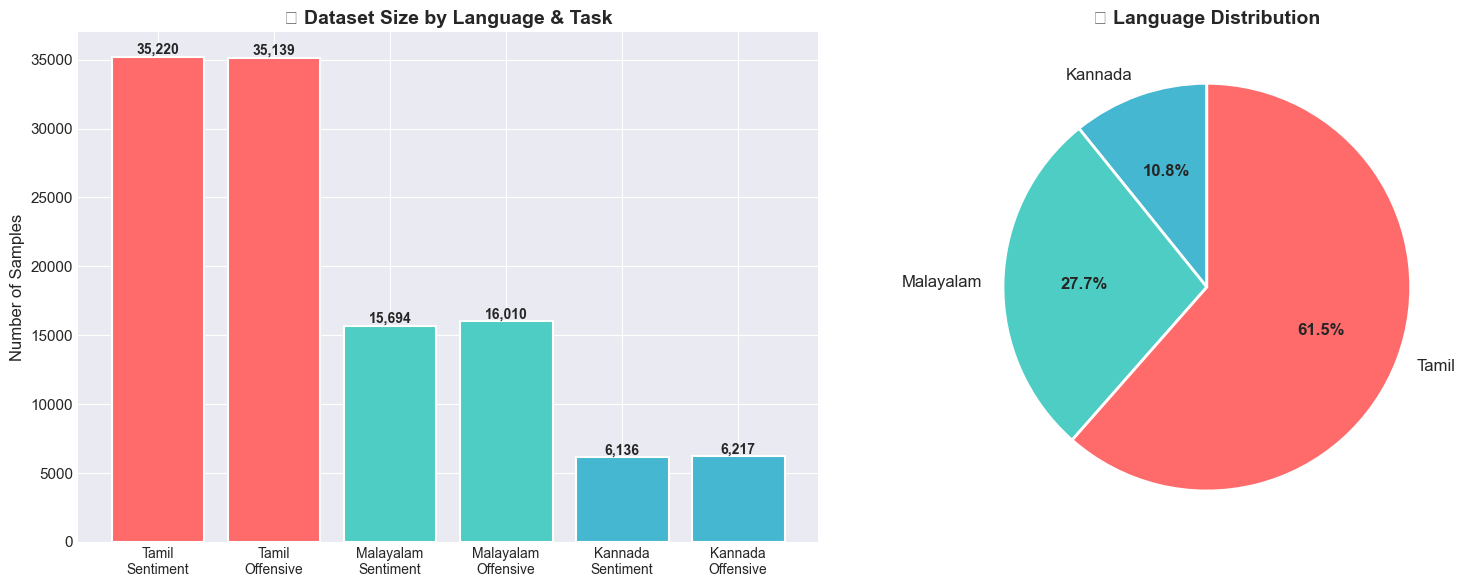

✅ Saved: eda_dataset_sizes.png


In [3]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# --- Bar chart: Samples per dataset ---
colors = {'Tamil': '#FF6B6B', 'Malayalam': '#4ECDC4', 'Kannada': '#45B7D1'}
langs = summary_df['Language'].tolist()
tasks = summary_df['Task'].tolist()
samples = summary_df['Samples'].tolist()
bar_colors = [colors[l] for l in langs]

bars = axes[0].bar(range(len(summary_df)), samples, color=bar_colors, edgecolor='white', linewidth=1.5)
axes[0].set_xticks(range(len(summary_df)))
axes[0].set_xticklabels([f"{l}\n{t}" for l, t in zip(langs, tasks)], fontsize=10)
axes[0].set_ylabel("Number of Samples")
axes[0].set_title("📊 Dataset Size by Language & Task", fontsize=14, fontweight='bold')
for bar, val in zip(bars, samples):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 200,
                f'{val:,}', ha='center', fontsize=10, fontweight='bold')

# --- Pie chart: Language distribution ---
lang_totals = summary_df.groupby('Language')['Samples'].sum()
wedges, texts, autotexts = axes[1].pie(
    lang_totals.values,
    labels=lang_totals.index,
    autopct='%1.1f%%',
    colors=[colors[l] for l in lang_totals.index],
    startangle=90,
    textprops={'fontsize': 12},
    wedgeprops={'edgecolor': 'white', 'linewidth': 2},
)
for autotext in autotexts:
    autotext.set_fontweight('bold')
axes[1].set_title("🌍 Language Distribution", fontsize=14, fontweight='bold')

plt.tight_layout()
plt.savefig('eda_dataset_sizes.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Saved: eda_dataset_sizes.png")


## 3️⃣ Label Distribution Analysis

Examining class distributions to understand **label imbalance** — critical for model training.


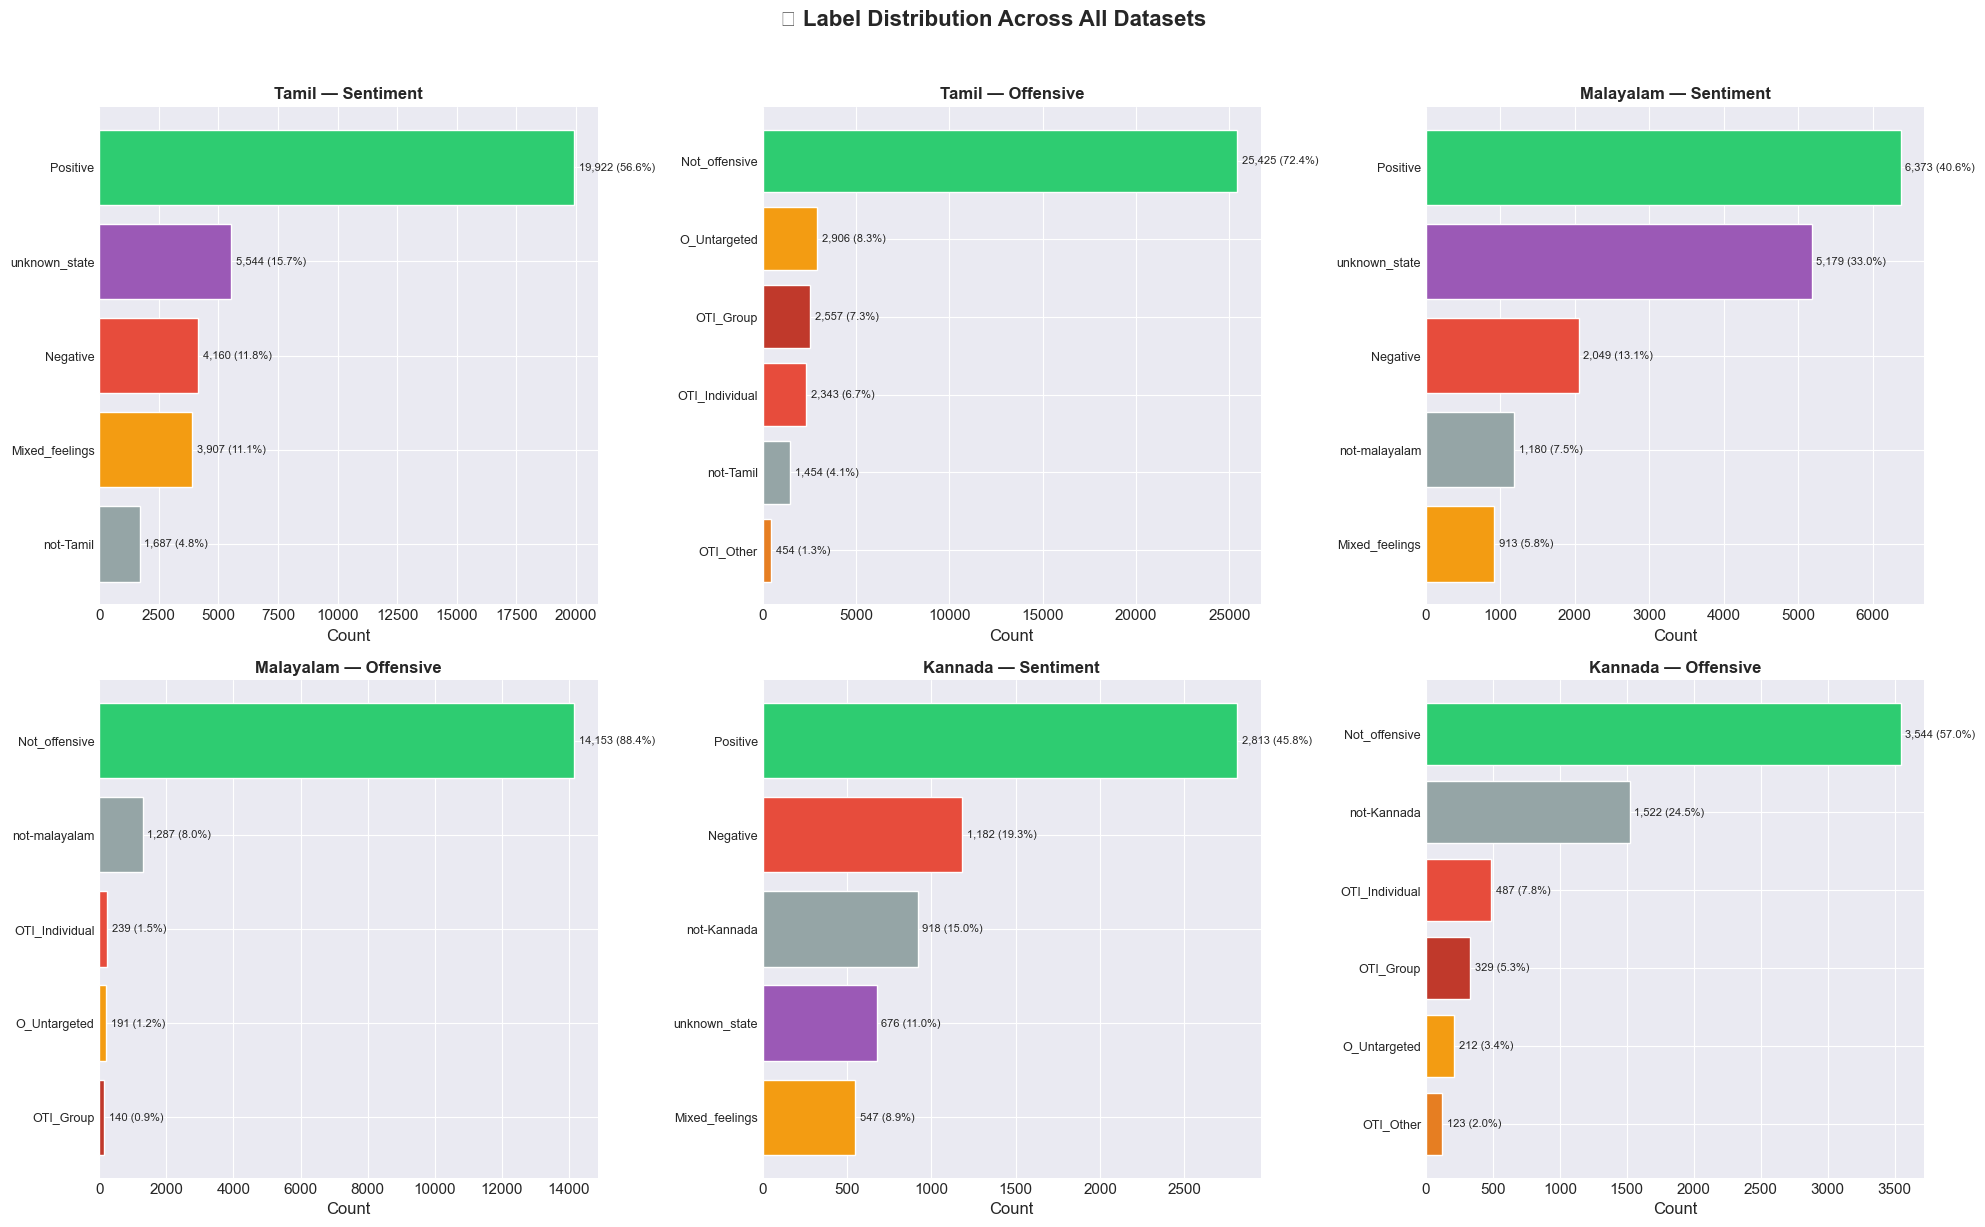

✅ Saved: eda_label_distributions.png


In [4]:
fig, axes = plt.subplots(2, 3, figsize=(20, 12))
fig.suptitle("📊 Label Distribution Across All Datasets", fontsize=16, fontweight='bold', y=1.02)

color_maps = {
    'Positive': '#2ecc71', 'Negative': '#e74c3c', 'Mixed_feelings': '#f39c12',
    'unknown_state': '#9b59b6', 'not-Tamil': '#95a5a6', 'not-Malayalam': '#95a5a6',
    'not-malayalam': '#95a5a6', 'not-Kannada': '#95a5a6',
    'Not_offensive': '#2ecc71', 'Offensive_Targeted_Insult_Individual': '#e74c3c',
    'Offensive_Targeted_Insult_Group': '#c0392b',
    'Offensive_Targeted_Insult_Other': '#e67e22',
    'Offensive_Untargetede': '#f39c12',
}

for idx, (key, df) in enumerate(datasets_raw.items()):
    row, col = idx // 3, idx % 3
    ax = axes[row][col]
    
    vc = df['label'].value_counts()
    bar_colors = [color_maps.get(l, '#3498db') for l in vc.index]
    
    bars = ax.barh(range(len(vc)), vc.values, color=bar_colors, edgecolor='white')
    ax.set_yticks(range(len(vc)))
    short_labels = [l.replace('Offensive_Targeted_Insult_', 'OTI_').replace('Offensive_Untargetede', 'O_Untargeted') for l in vc.index]
    ax.set_yticklabels(short_labels, fontsize=9)
    ax.set_xlabel("Count")
    
    lang = df['language'].iloc[0]
    task = df['task'].iloc[0]
    ax.set_title(f"{lang} — {task.capitalize()}", fontsize=12, fontweight='bold')
    
    # Add count labels
    for bar, val in zip(bars, vc.values):
        pct = val / len(df) * 100
        ax.text(bar.get_width() + max(vc.values)*0.01, bar.get_y() + bar.get_height()/2,
                f'{val:,} ({pct:.1f}%)', va='center', fontsize=8)
    
    ax.invert_yaxis()

plt.tight_layout()
plt.savefig('eda_label_distributions.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Saved: eda_label_distributions.png")


## 4️⃣ Text Length Analysis (Before Preprocessing)

Understanding the distribution of text lengths helps choose appropriate model architectures.


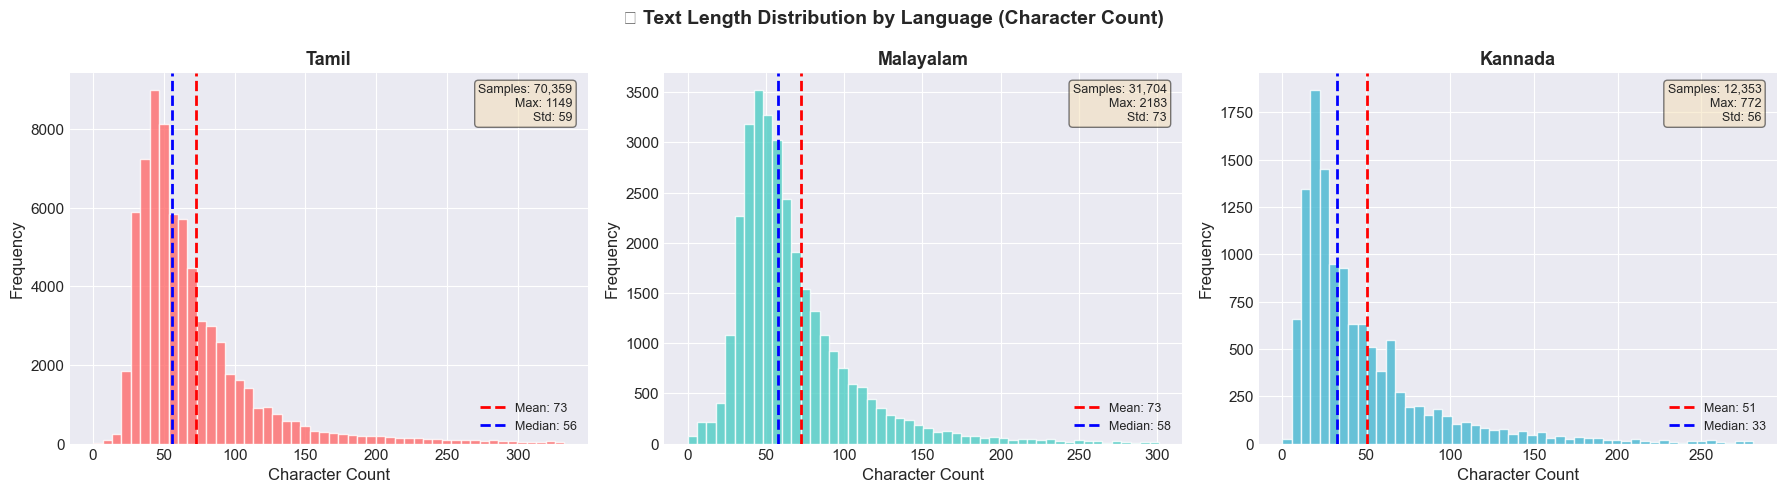

✅ Saved: eda_text_lengths.png


In [5]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle("📏 Text Length Distribution by Language (Character Count)", fontsize=14, fontweight='bold')

colors = {'Tamil': '#FF6B6B', 'Malayalam': '#4ECDC4', 'Kannada': '#45B7D1'}

for idx, lang in enumerate(['Tamil', 'Malayalam', 'Kannada']):
    ax = axes[idx]
    # Combine sentiment + offensive for each language
    lang_dfs = [df for df in datasets_raw.values() if df['language'].iloc[0] == lang]
    combined = pd.concat(lang_dfs)
    char_lens = combined['text'].str.len()
    
    ax.hist(char_lens, bins=50, color=colors[lang], edgecolor='white', alpha=0.8,
            range=(0, min(500, char_lens.quantile(0.99))))
    ax.axvline(char_lens.mean(), color='red', linestyle='--', linewidth=2, label=f'Mean: {char_lens.mean():.0f}')
    ax.axvline(char_lens.median(), color='blue', linestyle='--', linewidth=2, label=f'Median: {char_lens.median():.0f}')
    ax.set_title(f"{lang}", fontsize=13, fontweight='bold')
    ax.set_xlabel("Character Count")
    ax.set_ylabel("Frequency")
    ax.legend(fontsize=9)
    
    # Stats box
    stats_text = f"Samples: {len(combined):,}\nMax: {char_lens.max():.0f}\nStd: {char_lens.std():.0f}"
    ax.text(0.97, 0.97, stats_text, transform=ax.transAxes, fontsize=9,
            verticalalignment='top', horizontalalignment='right',
            bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))

plt.tight_layout()
plt.savefig('eda_text_lengths.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Saved: eda_text_lengths.png")


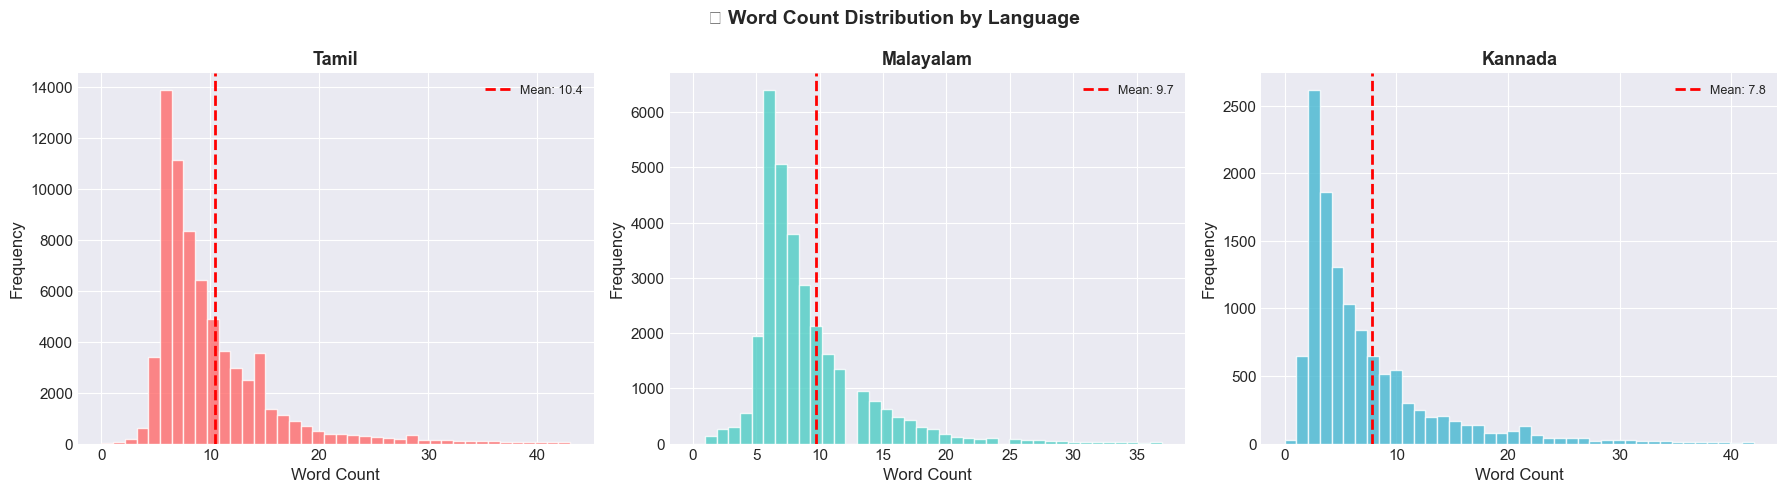

✅ Saved: eda_word_counts.png


In [6]:
# Word count distribution
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle("📝 Word Count Distribution by Language", fontsize=14, fontweight='bold')

for idx, lang in enumerate(['Tamil', 'Malayalam', 'Kannada']):
    ax = axes[idx]
    lang_dfs = [df for df in datasets_raw.values() if df['language'].iloc[0] == lang]
    combined = pd.concat(lang_dfs)
    word_counts = combined['text'].str.split().str.len()
    
    ax.hist(word_counts, bins=40, color=colors[lang], edgecolor='white', alpha=0.8,
            range=(0, min(50, word_counts.quantile(0.99))))
    ax.axvline(word_counts.mean(), color='red', linestyle='--', linewidth=2, label=f'Mean: {word_counts.mean():.1f}')
    ax.set_title(f"{lang}", fontsize=13, fontweight='bold')
    ax.set_xlabel("Word Count")
    ax.set_ylabel("Frequency")
    ax.legend(fontsize=9)

plt.tight_layout()
plt.savefig('eda_word_counts.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Saved: eda_word_counts.png")


## 5️⃣ Before vs After Preprocessing

Let's run the pipeline and compare raw vs preprocessed data.


In [7]:
# Run preprocessing on all datasets
pipeline = PreprocessingPipeline(
    filter_mode="remove",
    include_script_features=True,
    verbose=False,
)

datasets_processed = {}
for key, task in dataset_keys:
    df_raw = datasets_raw[key].copy()
    df_proc = pipeline.process_dataframe(df_raw, task=task, dataset_name=key)
    df_proc["language"] = datasets_raw[key]["language"].iloc[0]
    df_proc["task"] = task
    datasets_processed[key] = df_proc

print("✅ All datasets preprocessed!")
for key, df in datasets_processed.items():
    raw_count = len(datasets_raw[key])
    proc_count = len(df)
    reduction = (1 - proc_count/raw_count) * 100
    print(f"   {key:30s}  {raw_count:6,} → {proc_count:6,}  (−{reduction:.1f}%)")


10:05:34 | INFO     | LanguageFilter: Removed 1,687 non-target-language samples (4.8%)
10:05:36 | INFO     | LanguageFilter: Removed 1,454 non-target-language samples (4.1%)
10:05:38 | INFO     | LanguageFilter: Removed 1,180 non-target-language samples (7.5%)
10:05:40 | INFO     | LanguageFilter: Removed 1,287 non-target-language samples (8.0%)
10:05:41 | INFO     | LanguageFilter: Removed 918 non-target-language samples (15.0%)
10:05:41 | INFO     | LanguageFilter: Removed 1,522 non-target-language samples (24.5%)


✅ All datasets preprocessed!
   tamil_sentiment                 35,220 → 33,531  (−4.8%)
   tamil_offensive                 35,139 → 33,683  (−4.1%)
   mal_sentiment                   15,694 → 14,514  (−7.5%)
   mal_offensive                   16,010 → 14,723  (−8.0%)
   kannada_sentiment                6,136 →  5,218  (−15.0%)
   kannada_offensive                6,217 →  4,695  (−24.5%)


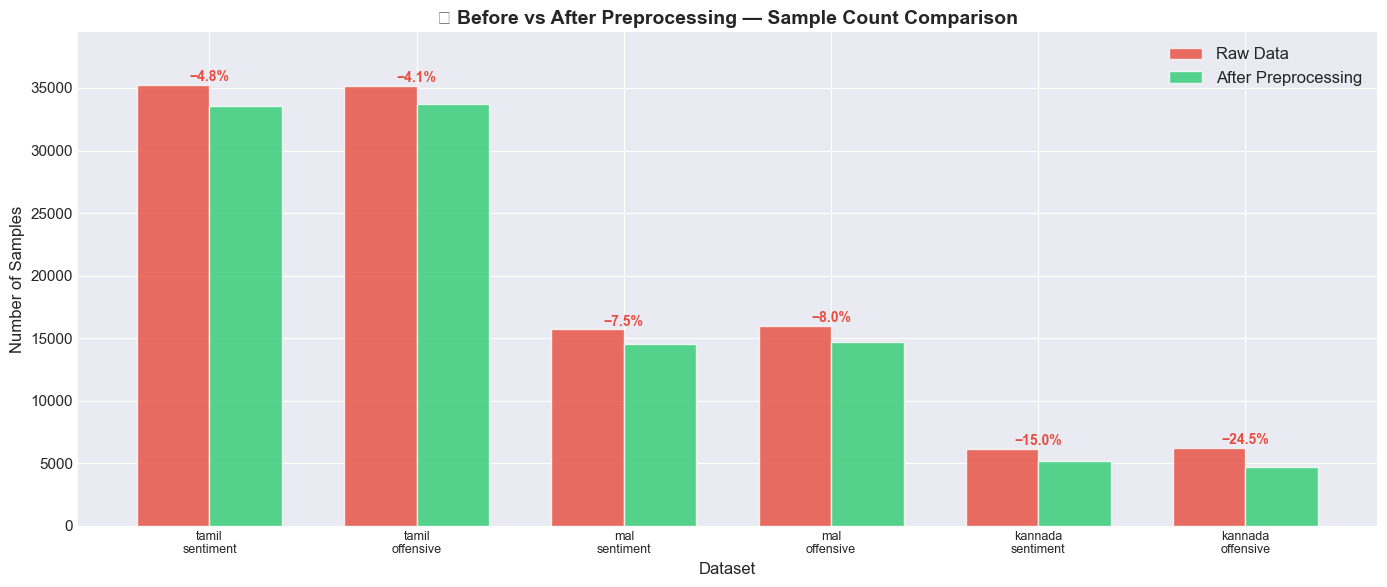

✅ Saved: eda_before_after.png


In [8]:
# Before vs After comparison bar chart
fig, ax = plt.subplots(figsize=(14, 6))

dataset_names = list(datasets_raw.keys())
x = np.arange(len(dataset_names))
width = 0.35

raw_counts = [len(datasets_raw[k]) for k in dataset_names]
proc_counts = [len(datasets_processed[k]) for k in dataset_names]

bars1 = ax.bar(x - width/2, raw_counts, width, label='Raw Data', color='#e74c3c', alpha=0.8, edgecolor='white')
bars2 = ax.bar(x + width/2, proc_counts, width, label='After Preprocessing', color='#2ecc71', alpha=0.8, edgecolor='white')

ax.set_xlabel('Dataset')
ax.set_ylabel('Number of Samples')
ax.set_title('📊 Before vs After Preprocessing — Sample Count Comparison', fontsize=14, fontweight='bold')
ax.set_xticks(x)
short_names = [k.replace('_', '\n') for k in dataset_names]
ax.set_xticklabels(short_names, fontsize=9)
ax.legend(fontsize=12)

# Add reduction % labels
for i, (r, p) in enumerate(zip(raw_counts, proc_counts)):
    reduction = (1 - p/r) * 100
    ax.text(i, max(r, p) + 300, f'−{reduction:.1f}%', ha='center', fontsize=10, fontweight='bold', color='#e74c3c')

ax.set_ylim(0, max(raw_counts) * 1.12)
plt.tight_layout()
plt.savefig('eda_before_after.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Saved: eda_before_after.png")


## 6️⃣ Before vs After — Text Cleaning Examples

Let's see actual examples of how the preprocessing transforms the text.


In [10]:
# Show before/after examples
print("=" * 90)
print("  BEFORE vs AFTER PREPROCESSING — Sample Texts")
print("=" * 90)

pipeline_demo = PreprocessingPipeline(filter_mode="remove", include_script_features=False, verbose=False)

for lang_key in ["tamil_sentiment", "mal_sentiment", "kannada_sentiment"]:
    df = datasets_raw[lang_key]
    lang = df["language"].iloc[0]
    print(f"\n{'─'*90}")
    print(f"  🌐 {lang}")
    print(f"{'─'*90}")
    
    count = 0
    for i in range(min(30, len(df))):
        original = df.iloc[i]["text"]
        cleaned = pipeline_demo.preprocess_text(original)
        # Show interesting examples (where cleaning made a difference)
        if original != cleaned and len(original) > 20 and count < 3:
            print(f"\n  📌 Sample {count+1}:")
            print(f"     BEFORE: {original[:120]}")
            print(f"     AFTER : {cleaned[:120]}")
            print(f"     LABEL : {df.iloc[i]['label']}")
            count += 1


  BEFORE vs AFTER PREPROCESSING — Sample Texts

──────────────────────────────────────────────────────────────────────────────────────────
  🌐 Tamil
──────────────────────────────────────────────────────────────────────────────────────────

  📌 Sample 1:
     BEFORE: First like button vijay setupati fans
     AFTER : first like button vijay setupati fans
     LABEL : unknown_state

  📌 Sample 2:
     BEFORE: Vetri ne dhanusha pudiche thongitu iru....
     AFTER : vetri ne dhanusha pudiche thongitu iru..
     LABEL : Positive

  📌 Sample 3:
     BEFORE: Ithu romba naal ku munnadi Short film'a pathathu! (Short film name: Kekka bukka kekka bukka)Short film'e Super'a irrukum
     AFTER : ithu romba naal ku munnadi short film'a pathathu! short film name kekka bukka kekka bukka short film'e super'a irrukum!
     LABEL : Positive

──────────────────────────────────────────────────────────────────────────────────────────
  🌐 Malayalam
───────────────────────────────────────────────────────────

## 7️⃣ Code-Mixing Analysis

The **Code-Mixing Index (CMI)** quantifies how much language switching happens in each comment.
- CMI = 0% → Monolingual (all one language)
- CMI = 50%+ → Highly code-mixed

This is the defining characteristic of this dataset.


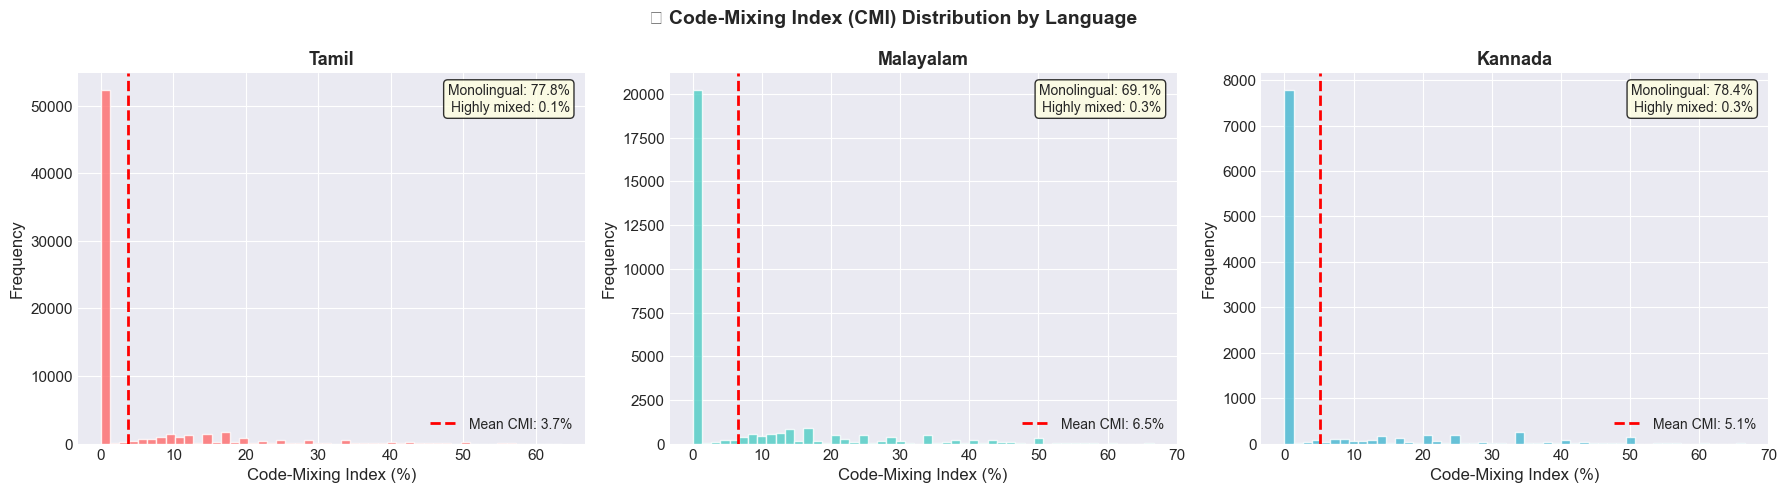

✅ Saved: eda_code_mixing.png


In [11]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle("🔀 Code-Mixing Index (CMI) Distribution by Language", fontsize=14, fontweight='bold')

for idx, lang in enumerate(['Tamil', 'Malayalam', 'Kannada']):
    ax = axes[idx]
    lang_dfs = [df for df in datasets_processed.values() if df['language'].iloc[0] == lang]
    combined = pd.concat(lang_dfs)
    cmi = combined['code_mix_index']
    
    ax.hist(cmi, bins=50, color=colors[lang], edgecolor='white', alpha=0.8)
    ax.axvline(cmi.mean(), color='red', linestyle='--', linewidth=2, label=f'Mean CMI: {cmi.mean():.1f}%')
    ax.set_title(f"{lang}", fontsize=13, fontweight='bold')
    ax.set_xlabel("Code-Mixing Index (%)")
    ax.set_ylabel("Frequency")
    ax.legend(fontsize=10)
    
    # Stats
    mono_pct = (cmi == 0).mean() * 100
    high_pct = (cmi > 50).mean() * 100
    stats_text = f"Monolingual: {mono_pct:.1f}%\nHighly mixed: {high_pct:.1f}%"
    ax.text(0.97, 0.97, stats_text, transform=ax.transAxes, fontsize=10,
            verticalalignment='top', horizontalalignment='right',
            bbox=dict(boxstyle='round', facecolor='lightyellow', alpha=0.8))

plt.tight_layout()
plt.savefig('eda_code_mixing.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Saved: eda_code_mixing.png")


## 8️⃣ Dominant Script Distribution

Each comment is classified by its dominant script — the script with the most characters.


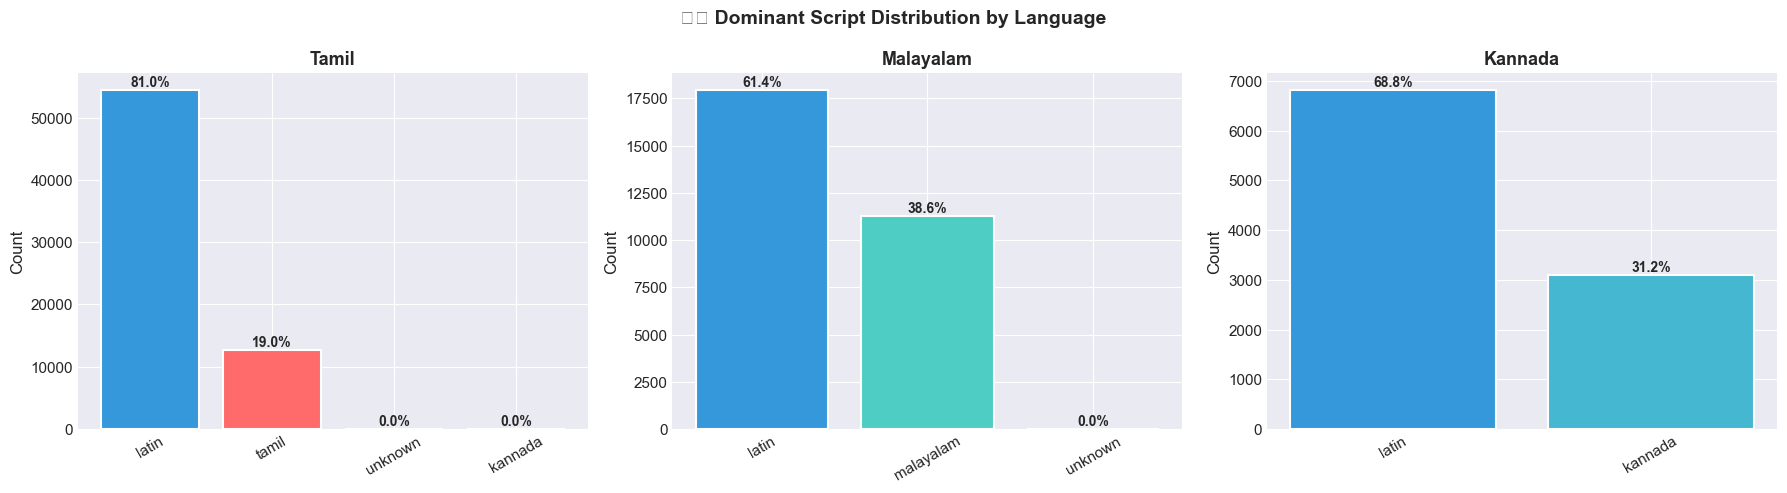

✅ Saved: eda_script_distribution.png


In [12]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle("✍️ Dominant Script Distribution by Language", fontsize=14, fontweight='bold')

for idx, lang in enumerate(['Tamil', 'Malayalam', 'Kannada']):
    ax = axes[idx]
    lang_dfs = [df for df in datasets_processed.values() if df['language'].iloc[0] == lang]
    combined = pd.concat(lang_dfs)
    vc = combined['dominant_script'].value_counts()
    
    script_colors = {
        'latin': '#3498db', 'tamil': '#FF6B6B', 'malayalam': '#4ECDC4',
        'kannada': '#45B7D1', 'devanagari': '#f39c12', 'unknown': '#95a5a6'
    }
    bar_colors = [script_colors.get(s, '#95a5a6') for s in vc.index]
    
    bars = ax.bar(vc.index, vc.values, color=bar_colors, edgecolor='white', linewidth=1.5)
    ax.set_title(f"{lang}", fontsize=13, fontweight='bold')
    ax.set_ylabel("Count")
    ax.tick_params(axis='x', rotation=30)
    
    for bar, val in zip(bars, vc.values):
        pct = val / len(combined) * 100
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + max(vc.values)*0.01,
                f'{pct:.1f}%', ha='center', fontsize=10, fontweight='bold')

plt.tight_layout()
plt.savefig('eda_script_distribution.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Saved: eda_script_distribution.png")


## 9️⃣ Sentiment / Offensive Labels vs Code-Mixing

Does the degree of code-mixing correlate with sentiment or offensiveness?


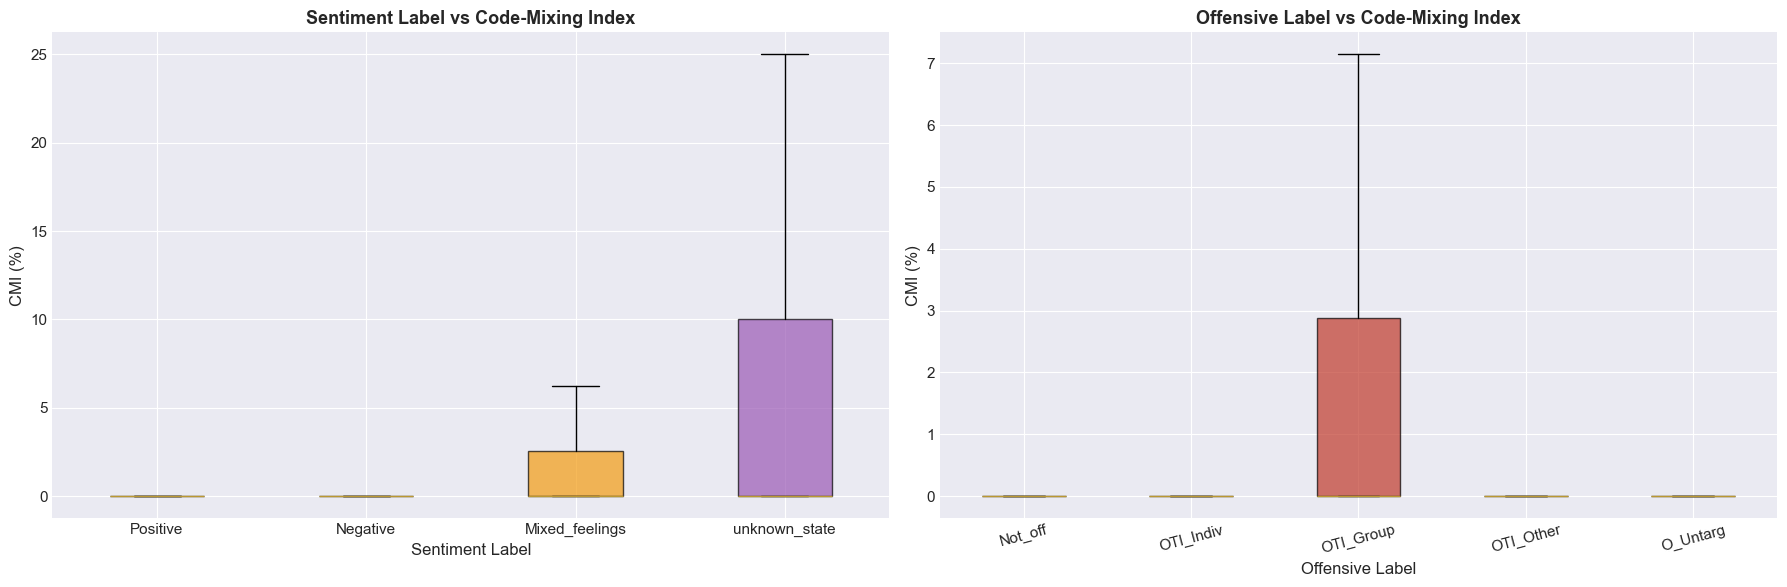

✅ Saved: eda_label_vs_cmi.png


In [13]:
fig, axes = plt.subplots(1, 2, figsize=(18, 6))

# --- Sentiment vs CMI ---
ax = axes[0]
sentiment_dfs = [df for k, df in datasets_processed.items() if 'sentiment' in k]
sent_combined = pd.concat(sentiment_dfs)

label_order = ['Positive', 'Negative', 'Mixed_feelings', 'unknown_state']
sent_filtered = sent_combined[sent_combined['label'].isin(label_order)]

sent_cmi_data = []
for label in label_order:
    subset = sent_filtered[sent_filtered['label'] == label]['code_mix_index']
    sent_cmi_data.append(subset.values)

bp1 = ax.boxplot(sent_cmi_data, labels=label_order, patch_artist=True, showfliers=False)
sent_colors = ['#2ecc71', '#e74c3c', '#f39c12', '#9b59b6']
for patch, color in zip(bp1['boxes'], sent_colors):
    patch.set_facecolor(color)
    patch.set_alpha(0.7)
ax.set_title("Sentiment Label vs Code-Mixing Index", fontsize=13, fontweight='bold')
ax.set_ylabel("CMI (%)")
ax.set_xlabel("Sentiment Label")

# --- Offensive vs CMI ---
ax = axes[1]
offensive_dfs = [df for k, df in datasets_processed.items() if 'offensive' in k]
off_combined = pd.concat(offensive_dfs)

off_labels = ['Not_offensive', 'Offensive_Targeted_Insult_Individual',
              'Offensive_Targeted_Insult_Group', 'Offensive_Targeted_Insult_Other',
              'Offensive_Untargetede']
off_short = ['Not_off', 'OTI_Indiv', 'OTI_Group', 'OTI_Other', 'O_Untarg']
off_filtered = off_combined[off_combined['label'].isin(off_labels)]

off_cmi_data = []
for label in off_labels:
    subset = off_filtered[off_filtered['label'] == label]['code_mix_index']
    off_cmi_data.append(subset.values)

bp2 = ax.boxplot(off_cmi_data, labels=off_short, patch_artist=True, showfliers=False)
off_colors = ['#2ecc71', '#e74c3c', '#c0392b', '#e67e22', '#f39c12']
for patch, color in zip(bp2['boxes'], off_colors):
    patch.set_facecolor(color)
    patch.set_alpha(0.7)
ax.set_title("Offensive Label vs Code-Mixing Index", fontsize=13, fontweight='bold')
ax.set_ylabel("CMI (%)")
ax.set_xlabel("Offensive Label")
ax.tick_params(axis='x', rotation=15)

plt.tight_layout()
plt.savefig('eda_label_vs_cmi.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Saved: eda_label_vs_cmi.png")


## 🔟 Word Cloud — Most Frequent Words by Language


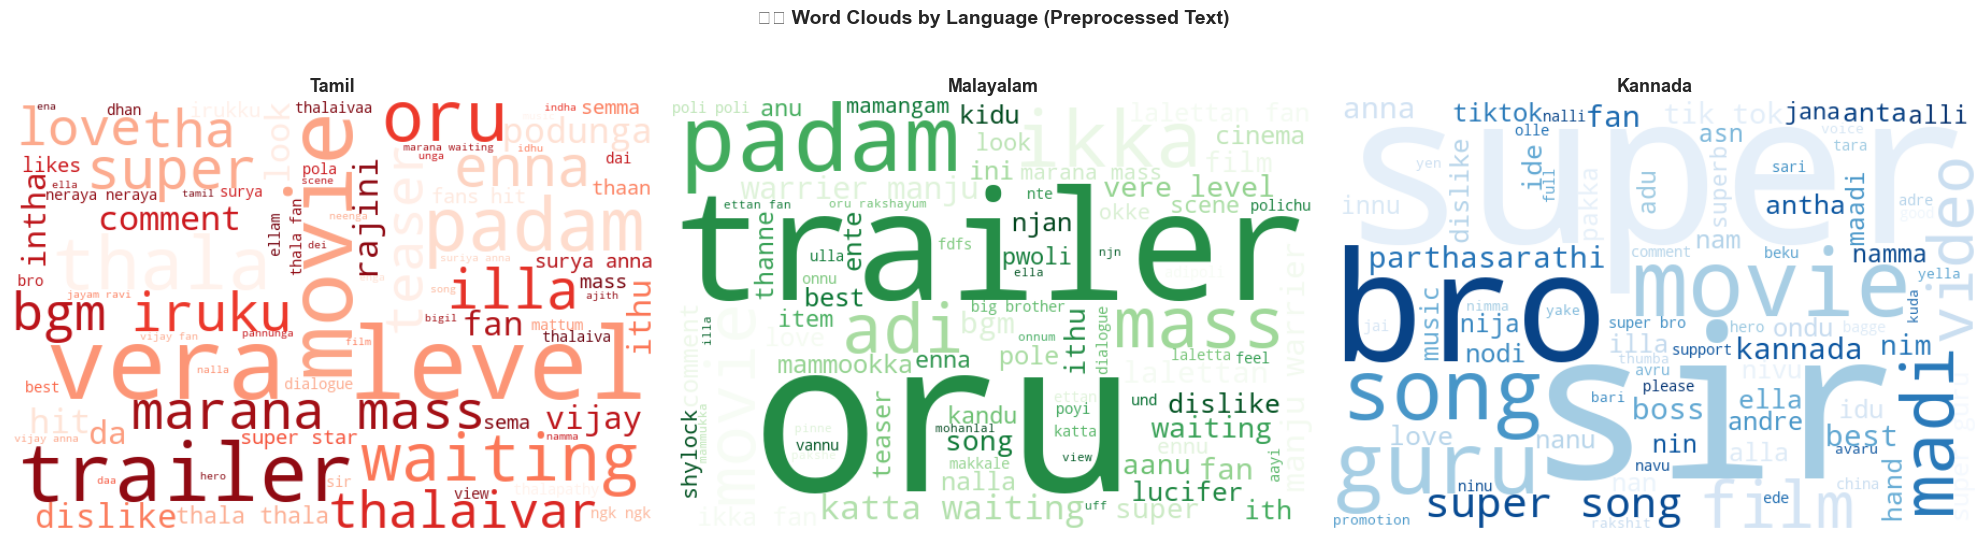

✅ Saved: eda_wordclouds.png


In [14]:
try:
    from wordcloud import WordCloud
    
    fig, axes = plt.subplots(1, 3, figsize=(20, 6))
    fig.suptitle("☁️ Word Clouds by Language (Preprocessed Text)", fontsize=14, fontweight='bold')
    
    wc_colors = {'Tamil': 'Reds', 'Malayalam': 'Greens', 'Kannada': 'Blues'}
    
    for idx, lang in enumerate(['Tamil', 'Malayalam', 'Kannada']):
        ax = axes[idx]
        lang_dfs = [df for df in datasets_processed.values() if df['language'].iloc[0] == lang]
        combined = pd.concat(lang_dfs)
        
        # Get only Latin-script words for the wordcloud (Dravidian scripts may not render)
        all_text = ' '.join(combined['text'].tolist())
        latin_words = ' '.join([w for w in all_text.split() if w.isascii() and len(w) > 2])
        
        if latin_words.strip():
            wc = WordCloud(width=600, height=400, background_color='white',
                          colormap=wc_colors[lang], max_words=80).generate(latin_words)
            ax.imshow(wc, interpolation='bilinear')
        ax.set_title(f"{lang}", fontsize=13, fontweight='bold')
        ax.axis('off')
    
    plt.tight_layout()
    plt.savefig('eda_wordclouds.png', dpi=150, bbox_inches='tight')
    plt.show()
    print("✅ Saved: eda_wordclouds.png")
except ImportError:
    print("⚠️ wordcloud not installed. Skipping word clouds.")
    print("   Install with: pip install wordcloud")


## 1️⃣1️⃣ Feature Correlation Heatmap


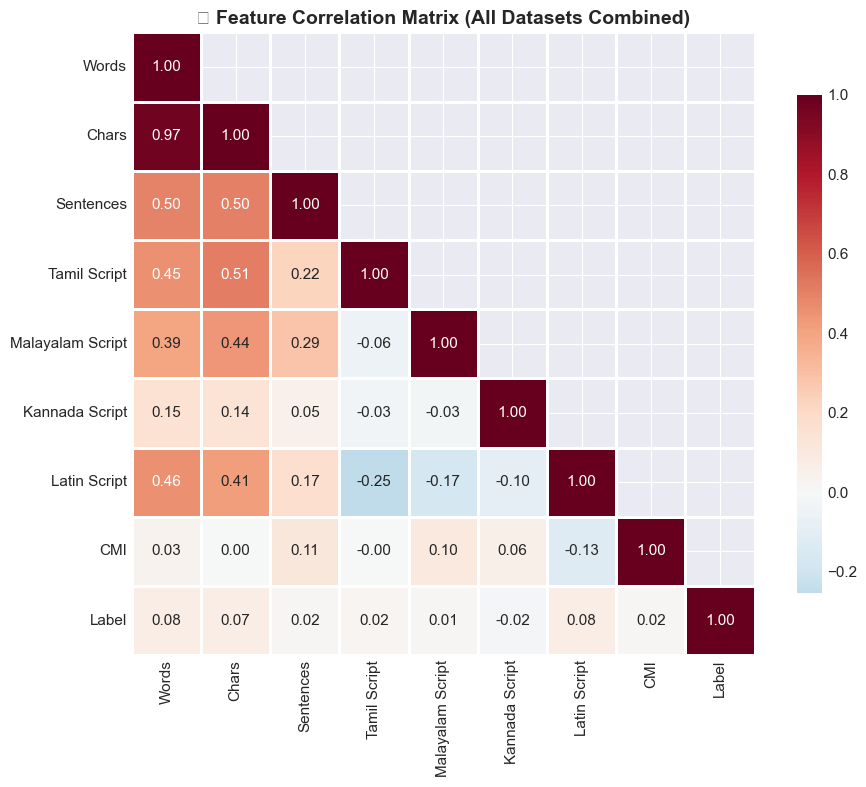

✅ Saved: eda_correlation.png


In [15]:
# Combine all processed datasets
all_processed = pd.concat(datasets_processed.values(), ignore_index=True)

# Select numeric features
feature_cols = ['word_count', 'char_count', 'sentence_count',
                'script_tamil', 'script_malayalam', 'script_kannada',
                'script_latin', 'code_mix_index', 'label_encoded']

corr_data = all_processed[feature_cols].copy()
corr_data.columns = ['Words', 'Chars', 'Sentences', 'Tamil Script',
                      'Malayalam Script', 'Kannada Script', 'Latin Script',
                      'CMI', 'Label']

fig, ax = plt.subplots(figsize=(10, 8))
corr_matrix = corr_data.corr()
mask = np.triu(np.ones_like(corr_matrix, dtype=bool), k=1)

sns.heatmap(corr_matrix, mask=mask, annot=True, fmt='.2f', cmap='RdBu_r',
            center=0, square=True, linewidths=1, ax=ax,
            cbar_kws={"shrink": 0.8})
ax.set_title("🔗 Feature Correlation Matrix (All Datasets Combined)", fontsize=14, fontweight='bold')

plt.tight_layout()
plt.savefig('eda_correlation.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Saved: eda_correlation.png")


## 1️⃣2️⃣ Text Length Distribution by Sentiment Label


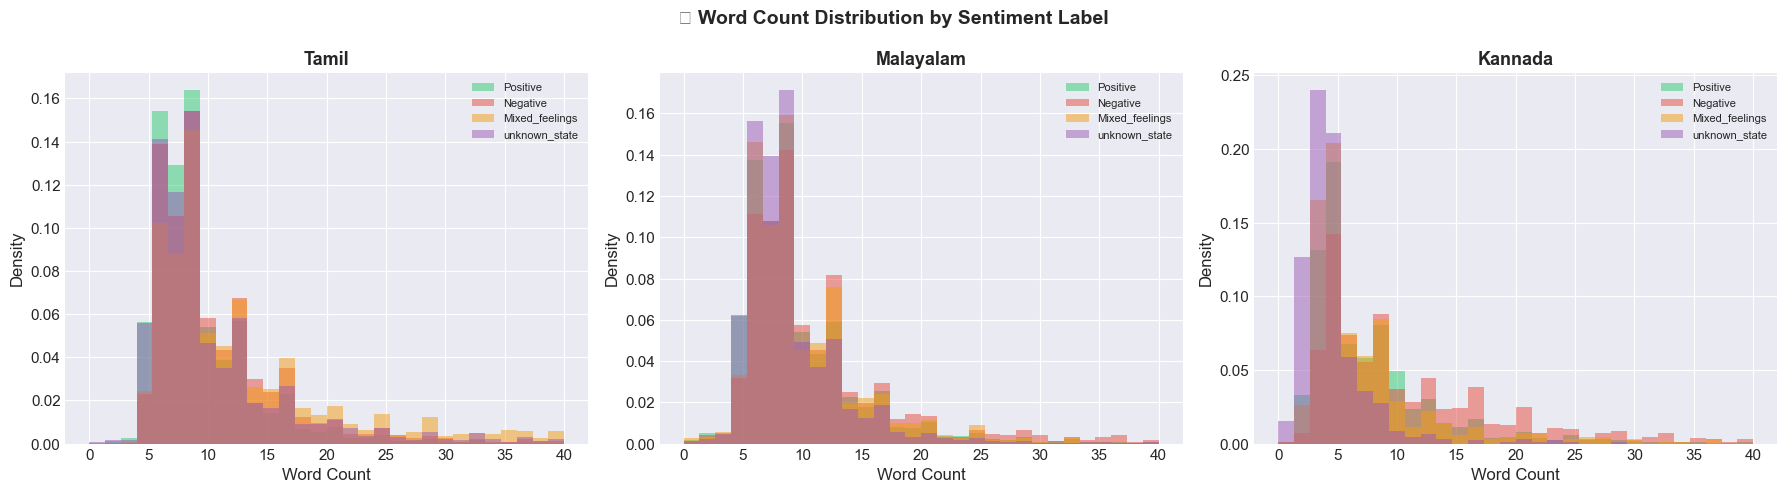

✅ Saved: eda_wordcount_by_label.png


In [16]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle("📏 Word Count Distribution by Sentiment Label", fontsize=14, fontweight='bold')

sent_colors = {'Positive': '#2ecc71', 'Negative': '#e74c3c', 
               'Mixed_feelings': '#f39c12', 'unknown_state': '#9b59b6'}

for idx, lang in enumerate(['Tamil', 'Malayalam', 'Kannada']):
    ax = axes[idx]
    lang_key = f"{'mal' if lang == 'Malayalam' else lang.lower()}_sentiment"
    if lang_key in datasets_processed:
        df = datasets_processed[lang_key]
        for label, color in sent_colors.items():
            subset = df[df['label'] == label]['word_count']
            if len(subset) > 0:
                ax.hist(subset, bins=30, alpha=0.5, color=color, label=label,
                       range=(0, 40), density=True)
        ax.set_title(f"{lang}", fontsize=13, fontweight='bold')
        ax.set_xlabel("Word Count")
        ax.set_ylabel("Density")
        ax.legend(fontsize=8)

plt.tight_layout()
plt.savefig('eda_wordcount_by_label.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Saved: eda_wordcount_by_label.png")


## 1️⃣3️⃣ Preprocessing Impact — Detailed Statistics


In [17]:
print("=" * 90)
print("  📊 PREPROCESSING IMPACT — DETAILED STATISTICS")
print("=" * 90)

for key in dataset_keys:
    dkey = key[0]
    raw = datasets_raw[dkey]
    proc = datasets_processed[dkey]
    
    raw_chars = raw['text'].str.len()
    proc_chars = proc['text'].str.len() if 'char_count' not in proc else proc['char_count']
    
    raw_words = raw['text'].str.split().str.len()
    proc_words = proc['word_count'] if 'word_count' in proc else proc['text'].str.split().str.len()
    
    lang = proc['language'].iloc[0]
    task = proc['task'].iloc[0]
    
    print(f"\n{'─'*70}")
    print(f"  {lang} — {task.capitalize()}")
    print(f"{'─'*70}")
    print(f"  Samples     : {len(raw):>8,} → {len(proc):>8,}  (removed {len(raw)-len(proc):,})")
    print(f"  Avg chars   : {raw_chars.mean():>8.1f} → {proc_chars.mean():>8.1f}")
    print(f"  Avg words   : {raw_words.mean():>8.1f} → {proc_words.mean():>8.1f}")
    print(f"  Max chars   : {raw_chars.max():>8.0f} → {proc_chars.max():>8.0f}")
    
    if 'code_mix_index' in proc.columns:
        cmi = proc['code_mix_index']
        print(f"  Avg CMI     : {cmi.mean():>8.1f}%")
        print(f"  Monolingual : {(cmi == 0).mean()*100:>7.1f}%")

print(f"\n{'='*90}")
total_raw = sum(len(datasets_raw[k[0]]) for k in dataset_keys)
total_proc = sum(len(datasets_processed[k[0]]) for k in dataset_keys)
print(f"  GRAND TOTAL : {total_raw:,} → {total_proc:,} samples")
print(f"  Overall reduction: {(1 - total_proc/total_raw)*100:.1f}%")
print(f"{'='*90}")


  📊 PREPROCESSING IMPACT — DETAILED STATISTICS

──────────────────────────────────────────────────────────────────────
  Tamil — Sentiment
──────────────────────────────────────────────────────────────────────
  Samples     :   35,220 →   33,531  (removed 1,689)
  Avg chars   :     72.7 →     71.0
  Avg words   :     10.4 →     10.4
  Max chars   :     1149 →     1071
  Avg CMI     :      3.7%
  Monolingual :    77.8%

──────────────────────────────────────────────────────────────────────
  Tamil — Offensive
──────────────────────────────────────────────────────────────────────
  Samples     :   35,139 →   33,683  (removed 1,456)
  Avg chars   :     72.9 →     71.1
  Avg words   :     10.4 →     10.4
  Max chars   :     1149 →     1071
  Avg CMI     :      3.7%
  Monolingual :    77.8%

──────────────────────────────────────────────────────────────────────
  Malayalam — Sentiment
──────────────────────────────────────────────────────────────────────
  Samples     :   15,694 →   14,514 

## 1️⃣4️⃣ Class Imbalance Ratio

Understanding imbalance is crucial for choosing the right loss function and sampling strategy.


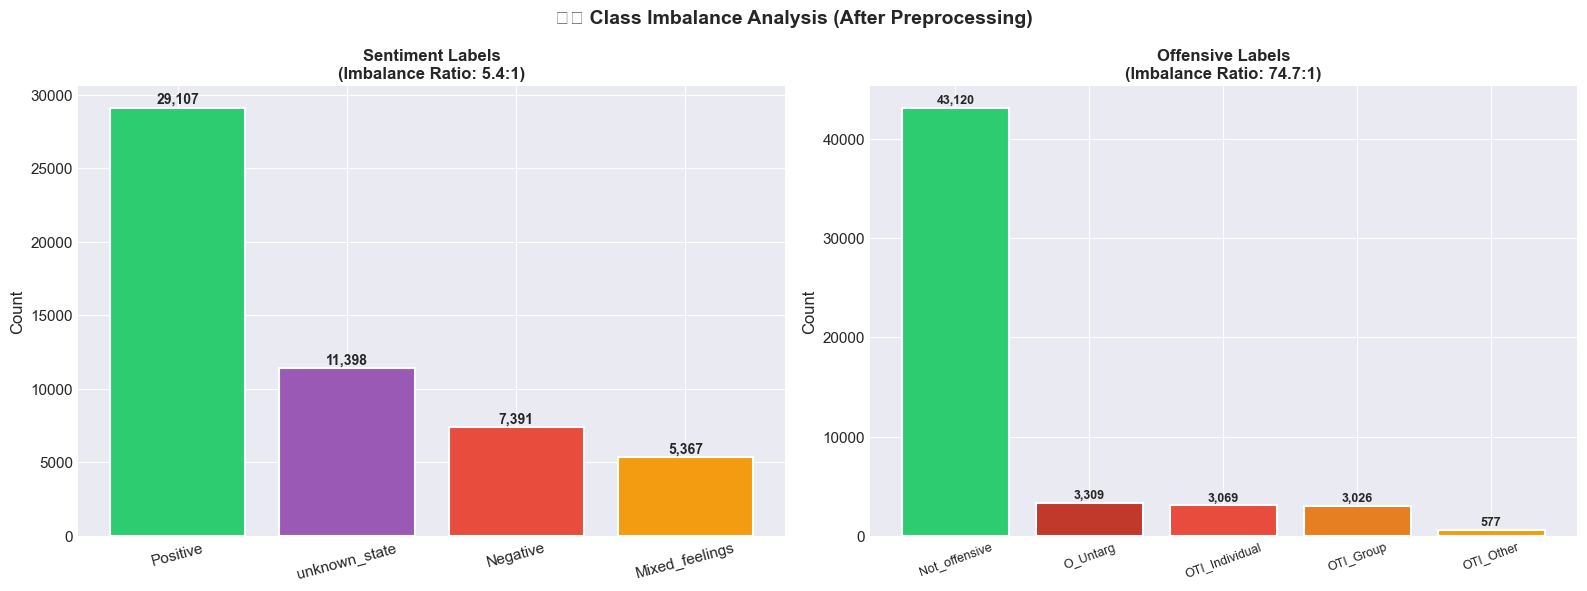

✅ Saved: eda_class_imbalance.png


In [18]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle("⚖️ Class Imbalance Analysis (After Preprocessing)", fontsize=14, fontweight='bold')

# Sentiment imbalance
ax = axes[0]
sent_combined = pd.concat([df for k, df in datasets_processed.items() if 'sentiment' in k])
vc = sent_combined['label'].value_counts()
imbalance_ratio = vc.max() / vc.min()

bars = ax.bar(vc.index, vc.values, color=['#2ecc71', '#9b59b6', '#e74c3c', '#f39c12'],
              edgecolor='white', linewidth=1.5)
ax.set_title(f"Sentiment Labels\n(Imbalance Ratio: {imbalance_ratio:.1f}:1)", fontsize=12, fontweight='bold')
ax.set_ylabel("Count")
ax.tick_params(axis='x', rotation=15)
for bar, val in zip(bars, vc.values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + max(vc.values)*0.01,
            f'{val:,}', ha='center', fontsize=10, fontweight='bold')

# Offensive imbalance
ax = axes[1]
off_combined = pd.concat([df for k, df in datasets_processed.items() if 'offensive' in k])
vc2 = off_combined['label'].value_counts()
imbalance_ratio2 = vc2.max() / vc2.min()

short_labels = [l.replace('Offensive_Targeted_Insult_', 'OTI_').replace('Offensive_Untargetede', 'O_Untarg') 
                for l in vc2.index]
bars2 = ax.bar(short_labels, vc2.values, 
               color=['#2ecc71', '#c0392b', '#e74c3c', '#e67e22', '#f39c12'],
               edgecolor='white', linewidth=1.5)
ax.set_title(f"Offensive Labels\n(Imbalance Ratio: {imbalance_ratio2:.1f}:1)", fontsize=12, fontweight='bold')
ax.set_ylabel("Count")
ax.tick_params(axis='x', rotation=20, labelsize=9)
for bar, val in zip(bars2, vc2.values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + max(vc2.values)*0.01,
            f'{val:,}', ha='center', fontsize=9, fontweight='bold')

plt.tight_layout()
plt.savefig('eda_class_imbalance.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Saved: eda_class_imbalance.png")


## 🏁 Summary of Key EDA Findings

### Dataset Characteristics
| Aspect | Finding |
|--------|---------|
| **Total samples** | ~114K raw → ~106K after preprocessing |
| **Languages** | Tamil (dominant), Malayalam, Kannada |
| **Tasks** | Sentiment (4 classes), Offensive (5 classes) |
| **Avg text length** | 8-10 words per comment |
| **Code-mixing** | Avg CMI 3.7-6.5% across languages |
| **Class imbalance** | Present in both tasks — needs handling |

### Key Observations
1. **Tamil dominates** the dataset (~61% of all samples)
2. **Most text is short** — social media comments averaging 8-10 words
3. **Code-mixing is present but moderate** — majority are monolingual, but ~15-22% show mixing
4. **Latin (English) script** is heavily present even in nominally Dravidian text
5. **Label imbalance** is significant — "Positive" and "Not_offensive" dominate
6. **Preprocessing removed ~7%** of data (non-target language + empty after cleaning)

### Recommendations for Model Training
- Use **class weights** or **oversampling** to handle label imbalance
- Consider **character-level models** or **multilingual transformers** for code-mixed text
- The **CMI feature** can be a valuable input signal
- **XLM-RoBERTa** or **MuRIL** are recommended pretrained models for this task
